# Airport Network Analysis — Communities and Resilience

This notebook examines regional communities and estimates how sensitive the network is to the removal of major hubs.

In [1]:
import sys
from pathlib import Path
import networkx as nx
import pandas as pd

sys.path.append(str(Path('../src').resolve()))
from graph_builder import build_graph

G = build_graph('../Data')
undirected_G = G.to_undirected()

In [37]:
airports = pd.read_csv("../Data/airports.dat", header=None)
routes = pd.read_csv("../Data/routes.dat", header=None)

In [38]:
airports.columns = [
    "Airport_ID",
    "Airport_Name",
    "City",
    "Country",
    "IATA",
    "ICAO",
    "Latitude",
    "Longitude",
    "Altitude",
    "Timezone",
    "DST",
    "Timezone_Database",
    "Type",
    "Source"
]


In [39]:
airport_lookup = airports[
    ["Airport_ID", "Airport_Name", "City", "Country", "IATA"]
].copy()

airport_lookup["Airport_ID"] = pd.to_numeric(
    airport_lookup["Airport_ID"],
    errors="coerce"
)

In [2]:
print("Number of nodes:", undirected_G.number_of_nodes())
print("Number of edges:", undirected_G.number_of_edges())

Number of nodes: 3214
Number of edges: 18859


## 2.Community Detection

The Louvain algorithm groups airports that have more route connections within the same group than with other groups.

In [3]:
communities = nx.community.louvain_communities(undirected_G, seed=42)
community_rows = []
for community_id, members in enumerate(communities, start=1):
    countries = pd.Series([G.nodes[node]['country'] for node in members]).value_counts().head(3)
    community_rows.append({
        'community': community_id,
        'airports': len(members),
        'dominant_countries': ', '.join(f'{country} ({count})' for country, count in countries.items())
    })

community_summary = pd.DataFrame(community_rows).sort_values('airports', ascending=False)
community_summary.head(15).reset_index(drop=True)

,community,airports,dominant_countries
0,14,732,"United States (410), Canada (70), Mexico (56)"
1,5,510,"France (54), United Kingdom (45), Spain (40)"
2,4,463,"India (67), Iran (38), Turkey (35)"
3,11,405,"Australia (113), Indonesia (63), Philippines (35)"
4,12,322,"China (172), Japan (62), Vietnam (20)"
5,13,212,"Brazil (122), Argentina (36), Peru (19)"
6,22,161,"Russia (103), Kazakhstan (17), Uzbekistan (11)"
7,15,131,United States (131)
8,1,110,Canada (110)
9,9,27,French Polynesia (27)


## 3. Random Failure Analysis

To assess whether the global airport network is more vulnerable to targeted hub failures than to random failures, airports are removed randomly at different failure levels. The experiment is repeated across multiple random trials to account for variation in the selected airports.

In [5]:
import random
random.seed(42)

removal_levels = [0, 1, 5, 10, 20, 50]
n_trials = 100

repeated_random_results = []

for removed_count in removal_levels:
    
    for trial in range(n_trials):
        
        # Randomly select airports to remove
        randomly_removed = random.sample(
            list(undirected_G.nodes()),
            removed_count
        )
        
        # Work on a copy of the original network
        remaining = undirected_G.copy()
        
        # Remove randomly selected airports
        remaining.remove_nodes_from(randomly_removed)
        
        # Find the largest connected component
        largest = (
            len(max(nx.connected_components(remaining), key=len))
            if remaining.number_of_nodes() > 0
            else 0
        )
        
        repeated_random_results.append({
            'airports_removed': removed_count,
            'trial': trial + 1,
            'largest_component': largest,
            'share_of_original_largest_component': largest / baseline_size
        })

repeated_random_resilience = pd.DataFrame(repeated_random_results)

repeated_random_resilience.head(10)

,airports_removed,trial,largest_component,share_of_original_largest_component
0,0,1,3188,1.0
1,0,2,3188,1.0
2,0,3,3188,1.0
3,0,4,3188,1.0
4,0,5,3188,1.0
5,0,6,3188,1.0
6,0,7,3188,1.0
7,0,8,3188,1.0
8,0,9,3188,1.0
9,0,10,3188,1.0


In [6]:
random_summary = (
    repeated_random_resilience
    .groupby('airports_removed')
    .agg(
        mean_largest_component=('largest_component', 'mean'),
        std_largest_component=('largest_component', 'std'),
        mean_share=('share_of_original_largest_component', 'mean'),
        min_share=('share_of_original_largest_component', 'min'),
        max_share=('share_of_original_largest_component', 'max')
    )
    .reset_index()
)

random_summary

,airports_removed,mean_largest_component,std_largest_component,mean_share,min_share,max_share
0,0,3188.00,0.000000,1.000000,1.000000,1.000000
1,1,3186.87,0.613896,0.999646,0.998118,1.000000
2,5,3181.38,3.404631,0.997923,0.992158,0.998745
3,10,3174.12,5.168436,0.995646,0.988708,0.997177
4,20,3160.48,12.235468,0.991368,0.960163,0.993726
5,50,3118.97,15.832746,0.978347,0.948871,0.983689


In [36]:
print(airports.columns.tolist())
print(airports.shape)

['Airport_ID', 'Airport_Name', 'City', 'Country', 'IATA', 'ICAO', 'Latitude', 'Longitude', 'Altitude', 'Timezone', 'DST', 'Timezone_Database', 'Type', 'Source']
(7698, 14)


In [24]:
degree_centrality = nx.degree_centrality(undirected_G)

degree_ranking = (
    pd.DataFrame(
        degree_centrality.items(),
        columns=["airport_id", "degree_centrality"]
    )
    .sort_values("degree_centrality", ascending=False)
)

degree_ranking.head(20)

,airport_id,degree_centrality
282,580,0.077186
191,340,0.075941
628,1382,0.074697
770,1701,0.072518
1809,3682,0.067538
1885,3830,0.064115
1642,3364,0.063803
196,346,0.059757
2016,4029,0.058512
1800,3670,0.058512


In [40]:
top_hubs = degree_ranking.merge(
    airport_lookup,
    left_on="airport_id",
    right_on="Airport_ID",
    how="left"
)

top_hubs[
    [
        "airport_id",
        "IATA",
        "Airport_Name",
        "City",
        "Country",
        "degree_centrality"
    ]
].head(20)

,airport_id,IATA,Airport_Name,City,Country,degree_centrality
0,580,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands,0.077186
1,340,FRA,Frankfurt am Main Airport,Frankfurt,Germany,0.075941
2,1382,CDG,Charles de Gaulle International Airport,Paris,France,0.074697
3,1701,ISL,Atatürk International Airport,Istanbul,Turkey,0.072518
4,3682,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,0.067538
5,3830,ORD,Chicago O'Hare International Airport,Chicago,United States,0.064115
6,3364,PEK,Beijing Capital International Airport,Beijing,China,0.063803
7,346,MUC,Munich Airport,Munich,Germany,0.059757
8,4029,DME,Domodedovo International Airport,Moscow,Russia,0.058512
9,3670,DFW,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,0.058512


## 5. Degree-Targeted Failure Analysis

In [27]:
targeted_removal_levels = [0, 1, 5, 10, 20, 50]

targeted_results = []

# Airports ranked from highest to lowest degree centrality
ranked_airports = degree_ranking["airport_id"].tolist()

for removed_count in targeted_removal_levels:

    # Select the top-ranked airports
    targeted_removed = ranked_airports[:removed_count]

    # Copy the original network
    remaining = undirected_G.copy()

    # Remove the selected hubs
    remaining.remove_nodes_from(targeted_removed)

    # Find largest connected component
    largest = (
        len(max(nx.connected_components(remaining), key=len))
        if remaining.number_of_nodes() > 0
        else 0
    )

    targeted_results.append({
        "airports_removed": removed_count,
        "largest_component": largest,
        "share_of_original_largest_component":
            largest / baseline_size
    })

targeted_resilience = pd.DataFrame(targeted_results)

targeted_resilience

,airports_removed,largest_component,share_of_original_largest_component
0,0,3188,1.000000
1,1,3187,0.999686
2,5,3167,0.993413
3,10,3129,0.981493
4,20,3080,0.966123
5,50,2955,0.926913


## 6.Random v/s Targeted Failure Comparison


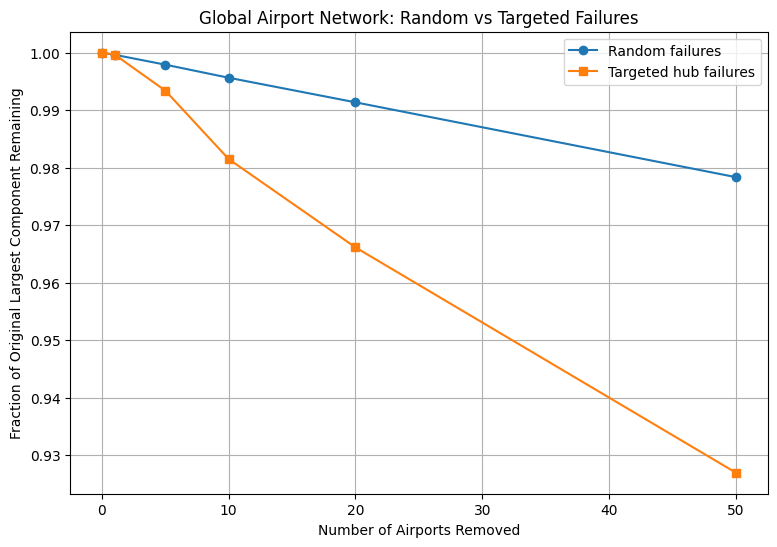

In [42]:
plt.figure(figsize=(9, 6))

plt.plot(
    random_summary["airports_removed"],
    random_summary["mean_share"],
    marker="o",
    label="Random failures"
)

plt.plot(
    targeted_resilience["airports_removed"],
    targeted_resilience["share_of_original_largest_component"],
    marker="s",
    label="Targeted hub failures"
)

plt.xlabel("Number of Airports Removed")
plt.ylabel("Fraction of Original Largest Component Remaining")
plt.title("Global Airport Network: Random vs Targeted Failures")

plt.legend()
plt.grid(True)
plt.show()

In [30]:
comparison = random_summary[
    ["airports_removed", "mean_share"]
].merge(
    targeted_resilience[
        ["airports_removed", "share_of_original_largest_component"]
    ],
    on="airports_removed"
)

comparison["targeted_damage"] = (
    comparison["mean_share"]
    - comparison["share_of_original_largest_component"]
)

comparison["targeted_damage_percent"] = (
    comparison["targeted_damage"] * 100
)

comparison

,airports_removed,mean_share,share_of_original_largest_component,targeted_damage,targeted_damage_percent
0,0,1.000000,1.000000,0.000000,0.000000
1,1,0.999646,0.999686,-0.000041,-0.004078
2,5,0.997923,0.993413,0.004511,0.451066
3,10,0.995646,0.981493,0.014153,1.415307
4,20,0.991368,0.966123,0.025245,2.524467
5,50,0.978347,0.926913,0.051434,5.143350


## 7. Betweenness Centrality

In [32]:
betweenness_centrality = nx.betweenness_centrality(
    undirected_G,
    normalized=True
)

betweenness_ranking = (
    pd.DataFrame(
        betweenness_centrality.items(),
        columns=["airport_id", "betweenness_centrality"]
    )
    .sort_values(
        "betweenness_centrality",
        ascending=False
    )
)

betweenness_ranking.head(20)

,airport_id,betweenness_centrality
628,1382,0.063563
1715,3484,0.060503
1861,3774,0.058427
1017,2188,0.055406
191,340,0.052432
282,580,0.051063
1642,3364,0.049788
1885,3830,0.046583
125,193,0.044345
770,1701,0.042428


In [33]:
top_betweenness = betweenness_ranking.merge(
    airport_lookup,
    left_on="airport_id",
    right_on="Airport_ID",
    how="left"
)

top_betweenness[
    [
        "airport_id",
        "IATA",
        "Airport_Name",
        "City",
        "Country",
        "betweenness_centrality"
    ]
].head(20)

,airport_id,IATA,Airport_Name,City,Country,betweenness_centrality
0,1382,CDG,Charles de Gaulle International Airport,Paris,France,0.063563
1,3484,LAX,Los Angeles International Airport,Los Angeles,United States,0.060503
2,3774,ANC,Ted Stevens Anchorage International Airport,Anchorage,United States,0.058427
3,2188,DXB,Dubai International Airport,Dubai,United Arab Emirates,0.055406
4,340,FRA,Frankfurt am Main Airport,Frankfurt,Germany,0.052432
5,580,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands,0.051063
6,3364,PEK,Beijing Capital International Airport,Beijing,China,0.049788
7,3830,ORD,Chicago O'Hare International Airport,Chicago,United States,0.046583
8,193,YYZ,Lester B. Pearson International Airport,Toronto,Canada,0.044345
9,1701,ISL,Atatürk International Airport,Istanbul,Turkey,0.042428


## 8. Degree vs Betweenness Centrality

In [34]:
centrality_comparison = top_hubs[
    ["airport_id", "IATA", "Airport_Name", "City", "Country",
     "degree_centrality"]
].merge(
    top_betweenness[
        ["airport_id", "betweenness_centrality"]
    ],
    on="airport_id",
    how="outer"
)

centrality_comparison = centrality_comparison.sort_values(
    "degree_centrality",
    ascending=False
)

centrality_comparison.head(20)

,airport_id,IATA,Airport_Name,City,Country,degree_centrality,betweenness_centrality
282,580,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands,0.077186,0.051063
191,340,FRA,Frankfurt am Main Airport,Frankfurt,Germany,0.075941,0.052432
628,1382,CDG,Charles de Gaulle International Airport,Paris,France,0.074697,0.063563
770,1701,ISL,Atatürk International Airport,Istanbul,Turkey,0.072518,0.042428
1809,3682,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,0.067538,0.029881
1885,3830,ORD,Chicago O'Hare International Airport,Chicago,United States,0.064115,0.046583
1642,3364,PEK,Beijing Capital International Airport,Beijing,China,0.063803,0.049788
196,346,MUC,Munich Airport,Munich,Germany,0.059757,0.016246
2016,4029,DME,Domodedovo International Airport,Moscow,Russia,0.058512,0.029678
1800,3670,DFW,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,0.058512,0.029891


## 9. Betweenness-Targeted Failure Analysis

In [35]:
betweenness_removal_levels = [0, 1, 5, 10, 20, 50]

betweenness_targeted_results = []

# Airports ranked from highest to lowest betweenness
ranked_betweenness_airports = (
    betweenness_ranking["airport_id"].tolist()
)

for removed_count in betweenness_removal_levels:

    # Select the most central airports according to betweenness
    targeted_removed = ranked_betweenness_airports[:removed_count]

    # Copy original network
    remaining = undirected_G.copy()

    # Remove selected airports
    remaining.remove_nodes_from(targeted_removed)

    # Find largest connected component
    largest = (
        len(max(nx.connected_components(remaining), key=len))
        if remaining.number_of_nodes() > 0
        else 0
    )

    betweenness_targeted_results.append({
        "airports_removed": removed_count,
        "largest_component": largest,
        "share_of_original_largest_component":
            largest / baseline_size
    })

betweenness_targeted_resilience = pd.DataFrame(
    betweenness_targeted_results
)

betweenness_targeted_resilience

,airports_removed,largest_component,share_of_original_largest_component
0,0,3188,1.000000
1,1,3186,0.999373
2,5,3086,0.968005
3,10,3067,0.962045
4,20,2956,0.927227
5,50,2741,0.859787


## 10.Conclusion

The resilience analysis demonstrates that the global airport network retains a substantial portion of its largest connected component even when structurally important airports are deliberately removed. In the betweenness-targeted experiment, the baseline largest connected component contained 3,188 airports. Removing one, five, ten, twenty, and fifty high-betweenness airports reduced this component to 3,186, 3,086, 3,067, 2,956, and 2,741 airports respectively.

In relative terms, approximately 99.94% of the baseline largest component remained after removing one airport, while 96.80%, 96.20%, 92.72%, and 85.98% remained after removing 5, 10, 20, and 50 airports respectively. This indicates that the network experiences a gradual reduction in connectivity rather than an immediate fragmentation under the tested targeted failures.

The analysis also demonstrates the usefulness of centrality measures for identifying structurally important airports. Degree centrality highlights highly connected hubs, whereas betweenness centrality identifies airports that occupy important intermediary positions within the network. Together with the random-failure experiment, these measures provide a framework for assessing the robustness and vulnerability of the global air transportation network.

Overall, the results suggest that the network has considerable structural resilience to the levels of targeted disruption examined in this study, while connectivity progressively decreases as more strategically important airports are removed.
